In [ ]:
# ============================
# 1. Cài đặt Kaggle API
# ============================
!pip install kaggle --quiet

import os

# Tạo folder lưu key
os.makedirs("/root/.kaggle", exist_ok=True)

# Upload kaggle.json (API key tải về từ Kaggle Account)
from google.colab import files
files.upload()   # chọn file kaggle.json

# Copy vào ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:
# ============================
# 2. Download dataset từ Kaggle
# Dataset: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
# ============================
!kaggle datasets download -d shayanfazeli/heartbeat
!unzip -o heartbeat.zip -d heartbeat_dataset


Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
  0% 0.00/98.8M [00:00<?, ?B/s]
100% 98.8M/98.8M [00:00<00:00, 1.72GB/s]
Archive:  heartbeat.zip
  inflating: heartbeat_dataset/mitbih_test.csv  
  inflating: heartbeat_dataset/mitbih_train.csv  
  inflating: heartbeat_dataset/ptbdb_abnormal.csv  
  inflating: heartbeat_dataset/ptbdb_normal.csv  


In [ ]:
# ============================
# 3. Import thư viện
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


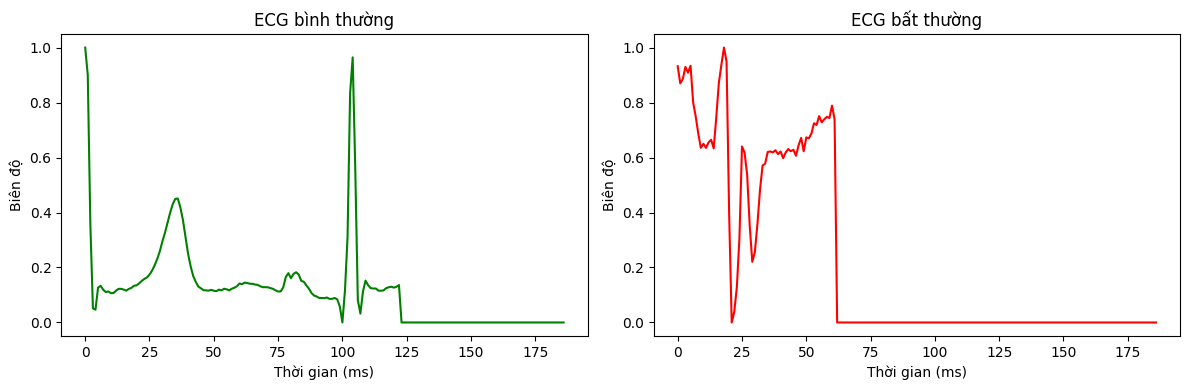

In [ ]:
# ============================
# 4. Load dataset từ thư mục tải về
# ============================
ptbdb_normal = pd.read_csv('heartbeat_dataset/ptbdb_normal.csv', header=None)
ptbdb_abnormal = pd.read_csv('heartbeat_dataset/ptbdb_abnormal.csv', header=None)
mitbih_train = pd.read_csv('heartbeat_dataset/mitbih_train.csv', header=None)
mitbih_test = pd.read_csv('heartbeat_dataset/mitbih_test.csv', header=None)

# ============================
# Vẽ mẫu ví dụ bất kỳ
# ============================
# Chọn 1 mẫu bất kỳ
sample_normal = ptbdb_normal.iloc[0, :-1].values
sample_abnormal = ptbdb_abnormal.iloc[0, :-1].values

# Vẽ 2 hình cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sample_normal, color='green')
axes[0].set_title("ECG bình thường")
axes[0].set_xlabel("Thời gian (ms)")
axes[0].set_ylabel("Biên độ")

axes[1].plot(sample_abnormal, color='red')
axes[1].set_title("ECG bất thường")
axes[1].set_xlabel("Thời gian (ms)")
axes[1].set_ylabel("Biên độ")

plt.tight_layout()
plt.show()


In [ ]:
# ============================
# 5. Tiền xử lý dữ liệu
# ============================
ptbdb = pd.concat([ptbdb_normal, ptbdb_abnormal])
mitbih = pd.concat([mitbih_train, mitbih_test])

# Combine datasets from Kaggle
X_kaggle = pd.concat([ptbdb.iloc[:, :-1], mitbih.iloc[:, :-1]])
y_kaggle = pd.concat([ptbdb.iloc[:, -1], mitbih.iloc[:, -1]])

# --- Thêm dữ liệu từ các file CSV mới ---
new_data_files = [
    '/content/drive/MyDrive/processed_data/processed_ekg_vernier.csv'
]

X_new_list = []
y_new_list = []

for file_path in new_data_files:
    try:
        # Giả định các file CSV mới cũng không có header và cột cuối cùng là nhãn
        df_new = pd.read_csv(file_path, header=None)
        X_new_list.append(df_new.iloc[:, :-1])
        y_new_list.append(df_new.iloc[:, -1])
        print(f"Đã tải {file_path}")
    except FileNotFoundError:
        print(f"File không tìm thấy: {file_path}. Bỏ qua.")
    except Exception as e:
        print(f"Lỗi khi đọc file {file_path}: {e}. Bỏ qua.")

if X_new_list: # Chỉ concat nếu có dữ liệu mới được tải
    X_new_combined = pd.concat(X_new_list)
    y_new_combined = pd.concat(y_new_list)

    # Kết hợp dữ liệu Kaggle và dữ liệu mới
    X = pd.concat([X_kaggle, X_new_combined]).values
    y = pd.concat([y_kaggle, y_new_combined]).values
else:
    # Nếu không có dữ liệu mới nào được tải, chỉ sử dụng dữ liệu Kaggle
    X = X_kaggle.values
    y = y_kaggle.values

# Handle NaN
X = np.nan_to_num(X)
y = np.nan_to_num(y)

# Correct labels (0 = normal, 1 = abnormal)
# Đảm bảo các nhãn khác 0 đều được chuyển thành 1 (abnormal)
# Đây là giả định rằng dữ liệu mới cũng theo quy tắc nhãn tương tự
if np.max(y) > 1: # Nếu có nhãn > 1, chuyển tất cả thành 1
    y[y != 0] = 1

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X).astype(np.float32)

# Save normalizaion for ESP32
np.save("scaler_mean.npy", scaler.mean_.astype(np.float32))
np.save("scaler_scale.npy", scaler.scale_.astype(np.float32))

print("X shape:", X.shape)
print("y shape:", y.shape)

# Reshape for CNN
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Convert labels to one-hot encoding
num_classes = 2 # Vẫn là 2 class: Normal và Abnormal
y_train = to_categorical(y_train.astype(int), num_classes=num_classes)
y_test = to_categorical(y_test.astype(int), num_classes=num_classes)

Đã tải /content/drive/MyDrive/processed_data/processed_ekg_vernier.csv
X shape: (124851, 187)
y shape: (124851,)


In [ ]:
# ============================
# 6. Xây dựng mô hình CNN
# ============================
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))
model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2752)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       352,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,522 (1.39 MB)

 Trainable params: 363,330 (1.39 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# ============================
# 7. Train mô hình
# ============================
history = model.fit(X_train, y_train, epochs=30, batch_size=64,
                    validation_data=(X_test, y_test), verbose=1)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")


Epoch 1/30
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8446 - loss: 0.4087 - val_accuracy: 0.9267 - val_loss: 0.1951
Epoch 2/30
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9194 - loss: 0.2099 - val_accuracy: 0.9494 - val_loss: 0.1429
Epoch 3/30
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9405 - loss: 0.1603 - val_accuracy: 0.9532 - val_loss: 0.1298
Epoch 4/30
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9514 - loss: 0.1325 - val_accuracy: 0.9616 - val_loss: 0.1104
Epoch 5/30
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9584 - loss: 0.1142 - val_accuracy: 0.9642 - val_loss: 0.1020
Epoch 6/30
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9647 - loss: 0.0996 - val_accuracy: 0.9702 - val_loss: 0.0873
Epoch 7/30
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9690 - loss: 0.0885 - val_accuracy: 0.9692 - val_loss: 0.0902
Epoch 8/30
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9725 - loss: 0.0793 -

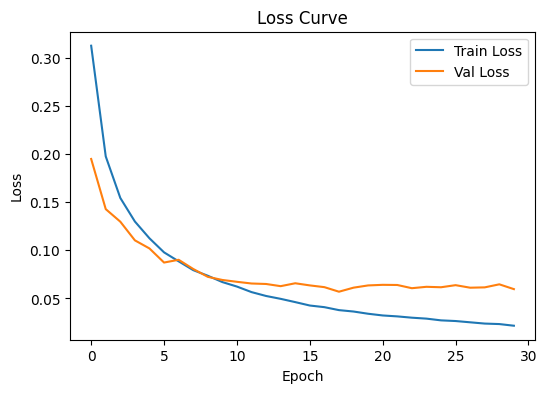

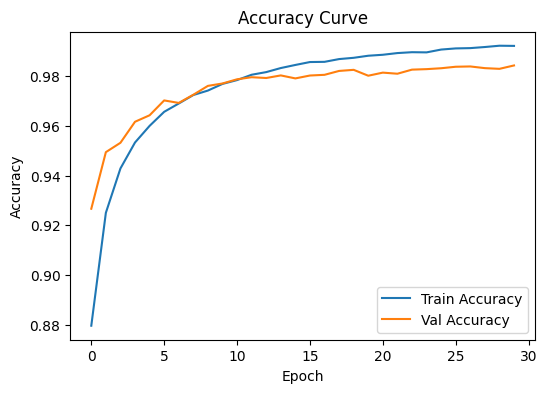

781/781 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


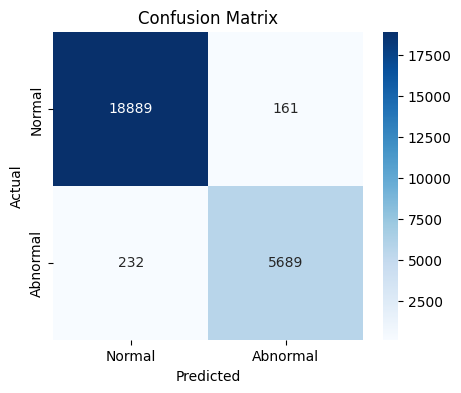


Classification Report:

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     19050
    Abnormal       0.97      0.96      0.97      5921

    accuracy                           0.98     24971
   macro avg       0.98      0.98      0.98     24971
weighted avg       0.98      0.98      0.98     24971



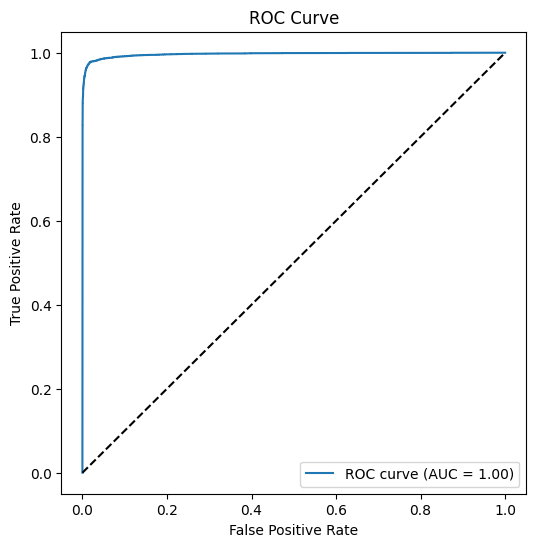

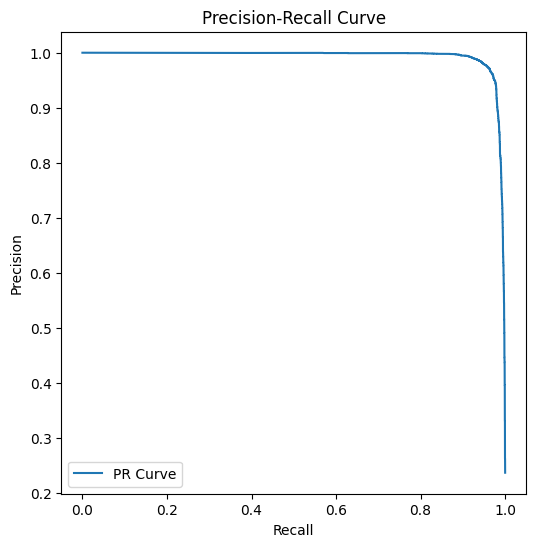

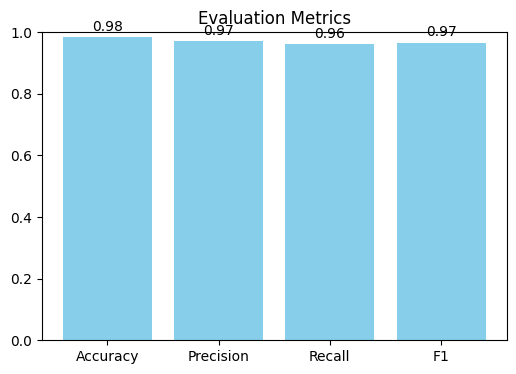

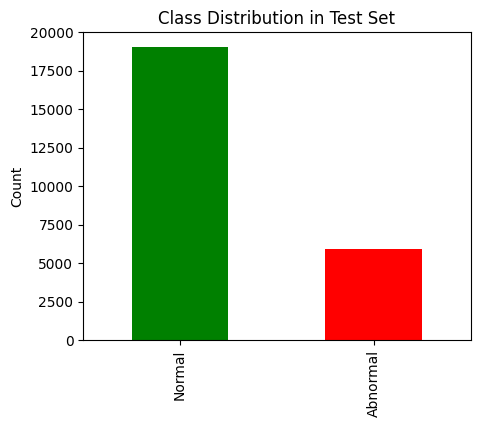

In [ ]:
# ============================
# 8. Vẽ và báo cáo kết quả
# ============================

# Loss & Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

# Predict
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Abnormal'],
            yticklabels=['Normal','Abnormal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Normal','Abnormal']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall Curve
precisions, recalls, _ = precision_recall_curve(y_true, y_prob[:,1])
plt.figure(figsize=(6,6))
plt.plot(recalls, precisions, label="PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Bar chart metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = [acc, prec, rec, f1]
names = ['Accuracy','Precision','Recall','F1']

plt.figure(figsize=(6,4))
plt.bar(names, metrics, color='skyblue')
plt.ylim(0,1)
for i, v in enumerate(metrics):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center')
plt.title('Evaluation Metrics')
plt.show()

# Histogram phân phối nhãn
plt.figure(figsize=(5,4))
pd.Series(y_true).value_counts().sort_index().plot(kind='bar', color=['green','red'])
plt.xticks([0,1], ['Normal','Abnormal'])
plt.ylabel('Count')
plt.title('Class Distribution in Test Set')
plt.show()


In [ ]:
# ============================
# 9. Xuất kết quả ra Excel
# ============================
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# 9.1. Loss & Accuracy theo epoch
df_history = pd.DataFrame({
    "epoch": range(1, len(history.history['loss'])+1),
    "train_loss": history.history['loss'],
    "val_loss": history.history['val_loss'],
    "train_acc": history.history['accuracy'],
    "val_acc": history.history['val_accuracy']
})

# 9.2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=['Actual_Normal','Actual_Abnormal'],
                        columns=['Pred_Normal','Pred_Abnormal'])

# 9.3. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
df_roc = pd.DataFrame({"fpr": fpr, "tpr": tpr})

# 9.4. Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob[:,1])
df_pr = pd.DataFrame({"precision": precisions, "recall": recalls, "threshold": list(thresholds)+[None]})

# 9.5. Metrics tổng quan
metrics_dict = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred),
    "Recall": recall_score(y_true, y_pred),
    "F1_score": f1_score(y_true, y_pred),
    "AUC": auc(fpr, tpr)
}
df_metrics = pd.DataFrame([metrics_dict])

# =======================
# Ghi vào 1 file Excel
# =======================
with pd.ExcelWriter("1D-CNN_model_EKG_Vernier_results.xlsx", engine="openpyxl") as writer:
    df_history.to_excel(writer, sheet_name="Training_History", index=False)
    df_cm.to_excel(writer, sheet_name="Confusion_Matrix")
    df_roc.to_excel(writer, sheet_name="ROC_Curve", index=False)
    df_pr.to_excel(writer, sheet_name="Precision_Recall", index=False)
    df_metrics.to_excel(writer, sheet_name="Summary_Metrics", index=False)

print("Đã lưu tất cả kết quả vào file 1D-CNN_model_EKG_Vernier_results.xlsx")

781/781 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Đã lưu tất cả kết quả vào file 1D-CNN_model_EKG_Vernier_results.xlsx


In [ ]:
# ============================
# 10. Xuất mô hình Keras
# ============================

# Lưu mô hình đã huấn luyện
# Định dạng HDF5 là một lựa chọn phổ biến cho Keras
model.save('ecg_cnn_model.h5')

print("Mô hình đã được lưu vào file ecg_cnn_model.h5")

Mô hình đã được lưu vào file ecg_cnn_model.h5


### 11. Chuyển đổi mô hình sang TensorFlow Lite và Lượng tử hóa

In [ ]:
import tensorflow as tf
import numpy as np # Thêm dòng này để đảm bảo np đã được import

# Tải mô hình Keras đã lưu
model = tf.keras.models.load_model('ecg_cnn_model.h5')

# Khởi tạo TensorFlow Lite Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Áp dụng lượng tử hóa sau huấn luyện (Post-training integer quantization)
# Điều này sẽ chuyển đổi trọng số và kích hoạt sang định dạng số nguyên 8-bit,
# giảm kích thước mô hình và tăng tốc độ suy luận trên các thiết bị nhúng.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Để thực hiện lượng tử hóa toàn bộ số nguyên, bạn cần cung cấp một tập dữ liệu đại diện.
# Nếu không, các hoạt động không thể lượng tử hóa sẽ được giữ ở dạng số thực 32-bit.
# Ở đây, chúng ta sử dụng một phần nhỏ của tập huấn luyện làm tập dữ liệu đại diện.

def representative_data_gen():
    # Sửa lỗi: Sử dụng slicing X_train[:100] để lấy 100 mẫu đầu tiên
    # Sau đó chuyển đổi kiểu dữ liệu và yield từng mẫu
    for input_value in X_train[:100].astype(np.float32):
        yield [input_value.reshape(1, 187, 1)] # Đảm bảo shape đầu vào khớp với mô hình

converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8  # Tùy chọn: đầu vào và đầu ra cũng là int8
converter.inference_output_type = tf.int8

tflite_model_quantized = converter.convert()

# Lưu mô hình TensorFlow Lite đã lượng tử hóa
with open('ecg_cnn_model_quantized.tflite', 'wb') as f:
    f.write(tflite_model_quantized)

print("Mô hình TensorFlow Lite đã được lượng tử hóa và lưu vào ecg_cnn_model_quantized.tflite")

# ===== 11b. Tạo model FLOAT32 cho ESP32 =====
converter_fp = tf.lite.TFLiteConverter.from_keras_model(model)
# Không đặt optimizations, không đặt supported_ops INT8, không đặt inference_input_type
tflite_model_fp = converter_fp.convert()

with open('ecg_cnn_model_float.tflite', 'wb') as f:
    f.write(tflite_model_fp)

print("Saved float32 TFLite model to ecg_cnn_model_float.tflite")


Saved artifact at '/tmp/tmpceq9nlp_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137961130319440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130320208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130319632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130321744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130315216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130320016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130322128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130321168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130323472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130321360: Ten

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Mô hình TensorFlow Lite đã được lượng tử hóa và lưu vào ecg_cnn_model_quantized.tflite
Saved artifact at '/tmp/tmp0slh9jia'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137961130319440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130320208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130319632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130321744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130315216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130320016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130322128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137961130321168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137

### 12. So sánh kích thước mô hình

In [ ]:
import os

keras_model_size = os.path.getsize('ecg_cnn_model.h5') / (1024 * 1024) # MB
tflite_model_size = os.path.getsize('ecg_cnn_model_quantized.tflite') / (1024 * 1024) # MB

print(f"Kích thước mô hình Keras gốc: {keras_model_size:.2f} MB")
print(f"Kích thước mô hình TensorFlow Lite đã lượng tử hóa: {tflite_model_size:.2f} MB")
print(f"Giảm kích thước: {(1 - tflite_model_size / keras_model_size) * 100:.2f}%")

Kích thước mô hình Keras gốc: 4.21 MB
Kích thước mô hình TensorFlow Lite đã lượng tử hóa: 0.36 MB
Giảm kích thước: 91.45%


Mô hình TensorFlow Lite đã được lượng tử hóa (`ecg_cnn_model_quantized.tflite`) là định dạng phù hợp nhất cho ESP32 S3 WROOM 1 N16R8. Kích thước nhỏ hơn và các phép tính số nguyên sẽ giúp nó chạy nhanh hơn và tiêu thụ ít tài nguyên hơn, cho phép xử lý gần như real-time trên các thiết bị nhúng.